In [1]:
import numpy as np
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
import scanpy 
import matplotlib.pyplot as plt
import pandas as pd
import scvi

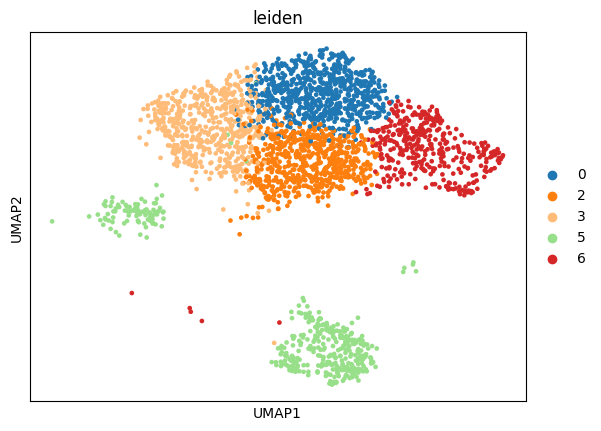

In [2]:
import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
mesh_CD = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCD_ccf_v1_250102 2.obj")
mesh_CV = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCV_ccf_v1_250102 2.obj")
allmeshes = [mesh_LC,mesh_CD,mesh_CV]

filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = scanpy.read_h5ad(filename)
scanpy.pl.umap(adata_mer, color = 'leiden')

In [3]:
adata_mer.obs

,slicename,x_CCF,y_CCF,z_CCF,mouse_name,mouse_sex,_scvi_batch,_scvi_labels,leiden,sex
neuron_id,,,,,,,,,,
103685216640203968188516774531086347883,MouseC_C2,409.606844,236.687088,179.309040,MouseC,M,0,0,5,M
107556232960175669029944473037950900912,MouseC_C2,409.104832,227.210884,174.501084,MouseC,M,0,0,5,M
110143770882700220040132120043038831763,MouseC_C2,407.519014,197.276290,266.738031,MouseC,M,0,0,3,M
113385467015087615676147138608792183276,MouseC_C2,410.125922,246.485426,165.601449,MouseC,M,0,0,5,M
120882274368051877867511817169740490916,MouseC_C2,405.119627,151.984390,256.980065,MouseC,M,0,0,2,M
...,...,...,...,...,...,...,...,...,...,...
96119208577592618782594425212756632908,MouseZM_ZM7p2,424.618466,166.654299,194.961194,MouseZM,M,23,0,6,M
9623349862178950852359237543126573460,MouseZM_ZM7p2,424.358181,171.836997,192.938647,MouseZM,M,23,0,6,M
96245750577479322584616409396904825217,MouseZM_ZM7p2,424.299410,171.174947,194.574443,MouseZM,M,23,0,2,M


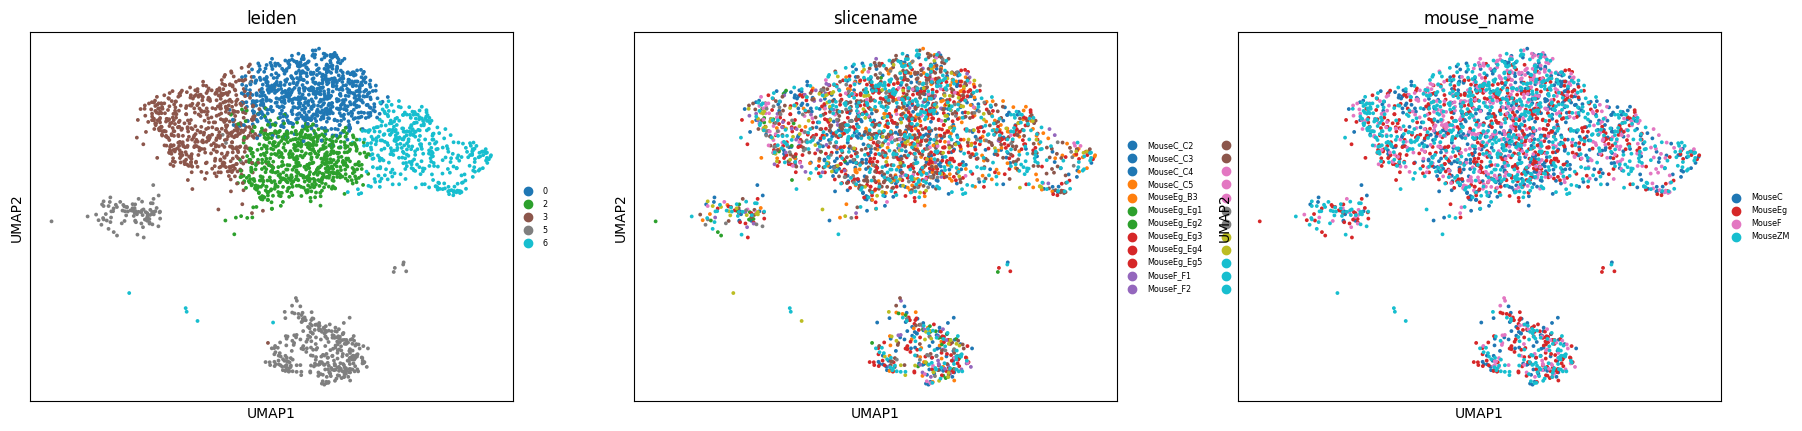

In [4]:
scanpy.pl.umap(adata_mer, color = ['leiden', 'slicename','mouse_name'],
               palette= 'tab10',s=30, legend_fontsize='xx-small')

In [5]:

def flip(a, xm):
        return(2*xm-a)

def get_hemi(S_mer, mesh):
    '''
    assume the axis of interest are both on the last axis. 
    '''
    xm = np.min(mesh.vertices[:,-1]) + np.ptp(mesh.vertices[:,-1])/2 # this is the center line to indicate the hemisphere 
    new_coords = S_mer.copy()
    new_coords[:,-1] = np.where(new_coords[:,-1] > xm, flip(new_coords[:,-1],xm), new_coords[:,-1])    
    return(new_coords)



def run_CCA(adata, mesh_LC,n_components=3,visualize = False):
    X_mer = adata.X        # Gene expression matrix (2800 x 314)
    S_mer = adata.obsm['spatial']  # Spatial coordinates matrix, e.g., (2800 x 2)
    S_mer = get_hemi(S_mer, mesh_LC)    
    scaler_X = StandardScaler().fit(X_mer)
    X_mer_scaled = scaler_X.transform(X_mer)
    scaler_S = StandardScaler().fit(S_mer)
    S_mer_scaled = scaler_S.transform(S_mer)
    
    if visualize:
        plt.figure(figsize = (5,5))
        plt.scatter(S_mer[:,2], S_mer[:,1],s=.3, alpha =.8);
        plt.gca().set_aspect('equal')
        plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        plt.gca().invert_yaxis()
        
    cca = CCA(n_components=n_components)
    cca.fit(X_mer_scaled, S_mer_scaled)
    X_c, S_c = cca.transform(X_mer_scaled, S_mer_scaled)

    return(cca, X_c, S_c)

In [6]:

def get_topgenes(adata_mer,cca,k):
    '''
    k is the CCA component ID
    '''
    loadings_df = pd.DataFrame({'gene': list(adata_mer.var_names),'loading': cca.x_weights_[:, k]})
    loadings_df['abs_loading'] = loadings_df['loading'].abs()
    loadings_sorted = loadings_df.sort_values('abs_loading', ascending=False)
    outlist = loadings_sorted['gene']
    return(outlist)

def make_plot_of_topgenes(adata_mer,cca,k,T = 5, title_info=None, cmap = 'jet'):
    topgenelist = get_topgenes(adata_mer,cca,k)
    
    fig, axes = plt.subplots(2,T,figsize=(2.5*T,6))     
    for i in range(T):
        top_gene = topgenelist.iloc[i]
        gene_index = list(adata_mer.var_names).index(top_gene)
        gene_expression = adata_mer.X[:, gene_index].toarray().flatten() if hasattr(adata_mer.X, "toarray") else adata_mer.X[:, gene_index]
        ordered = np.argsort(gene_expression)

        ax = axes[0,i]
        scat = ax.scatter(adata_mer.obsm['spatial'][ordered, 0], adata_mer.obsm['spatial'][ordered, 1],
                        c=gene_expression[ordered], cmap=cmap,s=.5)
        fig = ax.get_figure()
        fig.colorbar(scat, ax=ax)
        ax.set_aspect('equal')
        ax.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        ax.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        ax.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        ax.invert_yaxis();ax.set_yticks([]);ax.set_xticks([]);
        ax.set_ylabel(top_gene)
        
        
        ax = axes[1,i]
        ax.scatter(adata_mer.obsm['spatial'][ordered, 2], adata_mer.obsm['spatial'][ordered, 1],
                        c=gene_expression[ordered], cmap=cmap,s=.5)
        ax.set_aspect('equal')
        ax.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        ax.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        ax.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        ax.invert_yaxis();ax.set_yticks([]);ax.set_xticks([]);
    fig.suptitle(f'TOP genens for k={k} canocical component (for {title_info}!)')

In [7]:
def visualize_CCA(adata_sub, cca, scale_factor =50, title_info=None):
#     cca, X_c, S_c = run_CCA(adata_sub, mesh_LC,n_components=n_components, visualize=False)
    scale_factor = 30
    k = 0
    vector =(cca.y_weights_[:,k]) 
    vector_scaled = vector * (-1)**(vector[k]<0)*scale_factor

    plt.figure(figsize=(10, 8))
    plt.subplot(2,2,1)
    sca = plt.scatter(adata_sub.obsm['spatial'][:, 0], adata_sub.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
    # cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
    plt.gca().set_aspect('equal')
    start_point = (np.min(mesh_CV.vertices.T[0]), np.max(mesh_CV.vertices.T[1]))
    start_point = (400,220)
    end_point = (start_point[0] + vector_scaled[0], start_point[1] + vector_scaled[1])

    plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    plt.gca().invert_yaxis()
    plt.annotate("%.3f" %((-1)**(vector[k]<0)*canonical_correlations[k]),color='magenta',
                 xy=end_point,   # arrow tip
                 xytext=start_point,  # arrow tail
                 arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
                )
    plt.ylabel('component 1')

    plt.subplot(2,2,2)
    sca = plt.scatter(adata_sub.obsm['spatial'][:, 2], adata_sub.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
    cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
    plt.gca().set_aspect('equal')
    plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    plt.gca().invert_yaxis()



    k = 1
    vector =(cca.y_weights_[:,k]) 
    vector_scaled = vector * (-1)**(vector[k]<0)*scale_factor

    plt.subplot(2,2,3)
    sca = plt.scatter(adata_sub.obsm['spatial'][:, 0], adata_sub.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Blues',s=10)
    # cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
    plt.gca().set_aspect('equal')
    plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    plt.gca().invert_yaxis()
    plt.ylabel('component 2')


    plt.subplot(2,2,4)
    sca = plt.scatter(adata_sub.obsm['spatial'][:, 2], adata_sub.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Blues',s=10)
    cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
    plt.gca().set_aspect('equal')

    start_point = (np.min(adata_sub.obsm['spatial'][:, 2]), np.max(adata_sub.obsm['spatial'][:, 1]))
    start_point= (200,160)
    end_point = (start_point[0] + vector_scaled[2], start_point[1] + vector_scaled[1])


    plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')

    plt.annotate("%.3f" %((-1)**(vector[k]<0)*canonical_correlations[k]),color='magenta',
                 xy=end_point,   # arrow tip
                 xytext=start_point,  # arrow tail
                 arrowprops=dict(arrowstyle="->", color="magenta", lw=2))

    plt.gca().invert_yaxis()
    plt.suptitle(title_info)
    plt.tight_layout()

    plt.show()


Canonical correlations: [np.float64(0.9269336291357609), np.float64(0.890603682042351), np.float64(0.5925791999940102)]


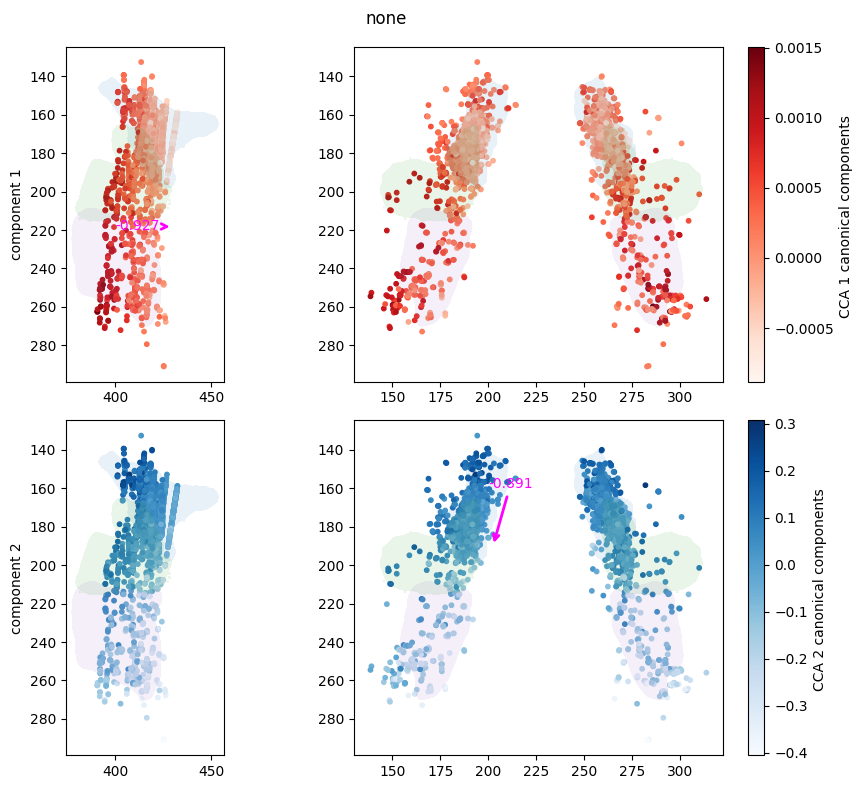

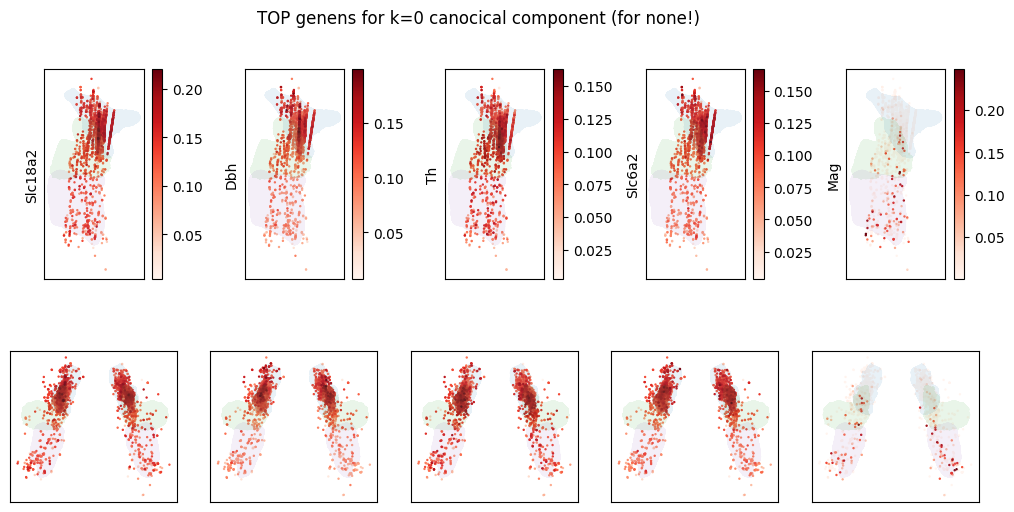

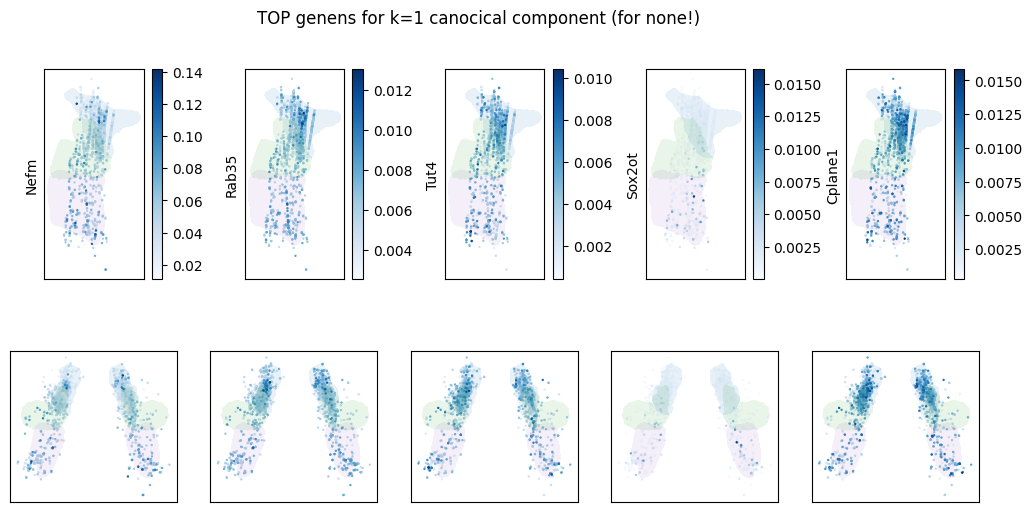

In [9]:
n_components = 3
cca, X_c, S_c = run_CCA(adata_mer, mesh_LC,n_components=n_components, visualize=False)
canonical_correlations = [np.corrcoef(X_c[:, i], S_c[:, i])[0, 1] for i in range(n_components)]
print("Canonical correlations:", canonical_correlations)

title_info = 'none'
visualize_CCA(adata_mer, cca, scale_factor =50, title_info=title_info)
make_plot_of_topgenes(adata_mer,cca,k=0,T = 5, title_info=title_info, cmap = 'Reds')
make_plot_of_topgenes(adata_mer,cca,k=1,T = 5, title_info=title_info, cmap = 'Blues')
